# 📚 Student Course Purchase Prediction
Predict whether a student will buy a course using learning-behavior data (Logistic Regression).

**Workflow:** Load data → Explore → Visualize → Insights → Train → Evaluate → Save model → Test

## 1. Import libraries

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

## 2. Load the dataset

In [2]:
df = pd.read_csv("../data/student_course_purchase.csv")
df.head()

,age,study_hours_per_week,previous_courses_completed,platform_visits_per_month,assignment_completion_rate,purchased_course
0,24,14,1,2,20,0
1,21,20,3,25,76,1
2,28,5,3,9,83,0
3,25,12,2,22,47,0
4,22,16,3,4,56,0


## 3. Data exploration

In [3]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.info()

Shape: (500, 6)
Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   age                         500 non-null    int64
 1   study_hours_per_week        500 non-null    int64
 2   previous_courses_completed  500 non-null    int64
 3   platform_visits_per_month   500 non-null    int64
 4   assignment_completion_rate  500 non-null    int64
 5   purchased_course            500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


In [4]:
df.describe().round(2)

,age,study_hours_per_week,previous_courses_completed,platform_visits_per_month,assignment_completion_rate,purchased_course
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,23.50,12.51,3.52,18.03,58.50,0.51
std,3.54,7.02,2.29,9.74,23.31,0.50
min,18.00,1.00,0.00,1.00,20.00,0.00
25%,20.00,6.00,2.00,10.00,39.00,0.00
50%,24.00,13.00,4.00,18.00,57.00,1.00
75%,27.00,19.00,6.00,26.00,79.00,1.00
max,29.00,24.00,7.00,34.00,99.00,1.00


In [5]:
print(df['purchased_course'].value_counts(normalize=True).round(3))

purchased_course
1    0.512
0    0.488
Name: proportion, dtype: float64


## 4. Visualizations

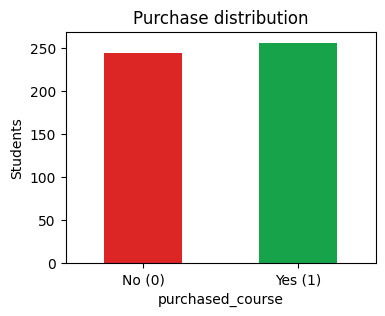

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
df['purchased_course'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#dc2626', '#16a34a'])
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
ax.set_title('Purchase distribution'); ax.set_ylabel('Students')
plt.show()

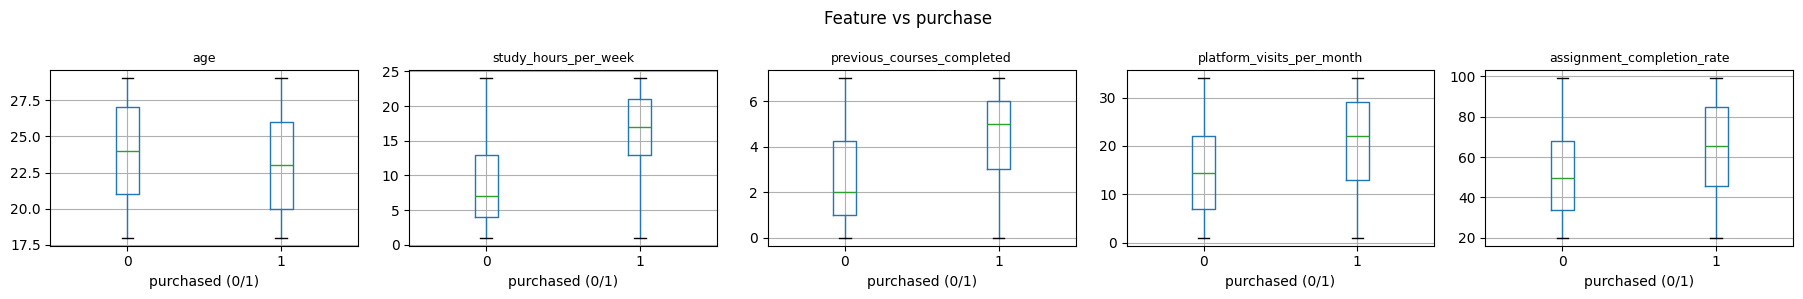

In [7]:
features = df.columns.drop('purchased_course')
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, features):
    df.boxplot(column=col, by='purchased_course', ax=ax)
    ax.set_title(col, fontsize=9); ax.set_xlabel('purchased (0/1)')
plt.suptitle('Feature vs purchase'); plt.tight_layout(); plt.show()

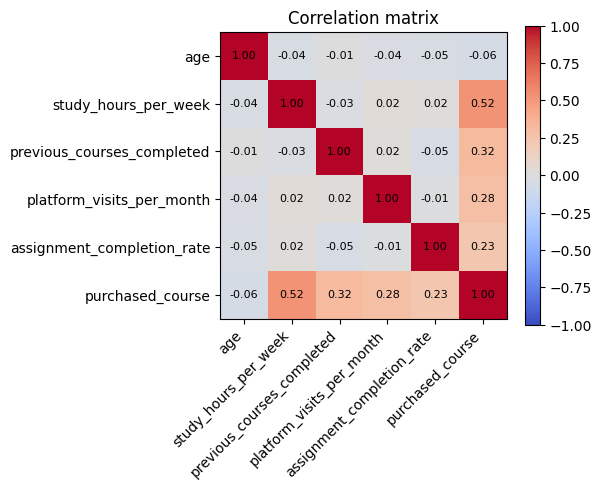

In [8]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right'); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im); ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

In [9]:
df.groupby('purchased_course').mean().round(1).T

purchased_course,0,1
age,23.7,23.3
study_hours_per_week,8.7,16.1
previous_courses_completed,2.8,4.2
platform_visits_per_month,15.2,20.7
assignment_completion_rate,53.1,63.7


## 5. Key insights from data analysis
1. **Study hours impact** – Buyers study ~16 hrs/week vs ~9 for non-buyers; it is the strongest predictor (correlation ≈ 0.52).
2. **Platform engagement** – Frequent visitors are more likely to buy (≈ 21 vs 15 visits/month).
3. **Previous course completion** – Students who finished more courses buy more (≈ 4.2 vs 2.8).
4. **Assignment completion** – Higher completion rates go with higher purchase likelihood (≈ 64% vs 53%).
5. **Age** – Age has almost no effect (correlation ≈ -0.06), so the "younger learners buy more" idea is not supported by this dataset.

## 6. Preprocessing & train-test split

In [10]:
X = df.drop('purchased_course', axis=1)
y = df['purchased_course']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (400, 5) Test: (100, 5)


## 7. Train the Logistic Regression model

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 8. Evaluate the model

In [12]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.72      0.89      0.80        44
           1       0.89      0.73      0.80        56

    accuracy                           0.80       100
   macro avg       0.81      0.81      0.80       100
weighted avg       0.82      0.80      0.80       100



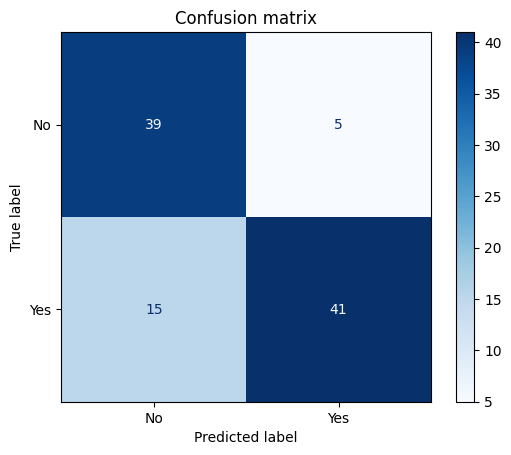

In [13]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['No', 'Yes']).plot(cmap='Blues')
plt.title('Confusion matrix'); plt.show()

In [14]:
scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5)
print("5-fold CV accuracy:", scores.round(3), "| mean:", scores.mean().round(3))

5-fold CV accuracy: [0.78 0.85 0.88 0.84 0.79] | mean: 0.828


## 9. Feature importance (model coefficients)

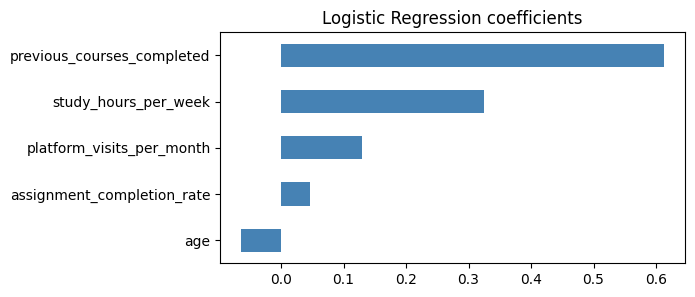

age                          -0.063446
assignment_completion_rate    0.045972
platform_visits_per_month     0.129904
study_hours_per_week          0.325123
previous_courses_completed    0.612886
dtype: float64

In [15]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
coef.plot(kind='barh', color='steelblue', figsize=(6, 3))
plt.title('Logistic Regression coefficients'); plt.show()
coef

## 10. Save the model
Saved into the backend folder so the API and frontend use this exact model.

In [16]:
with open("../backend/model/model.pkl", "wb") as f:
    pickle.dump(model, f)
print("model.pkl saved")

model.pkl saved


## 11. Test the saved model

In [17]:
loaded = pickle.load(open("../backend/model/model.pkl", "rb"))
student = pd.DataFrame([[22, 16, 3, 20, 75]], columns=X.columns)
print("Prediction:", "Likely to purchase" if loaded.predict(student)[0] == 1 else "Not likely to purchase")
print("Probability:", loaded.predict_proba(student)[0][1].round(3))

Prediction: Likely to purchase
Probability: 0.872
